<a href="https://colab.research.google.com/github/Jhon-theone/Challenge_TelecomX_Alura/blob/main/Challenge_TelecomX_Alura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge_TelecomX_LATAM**

Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

## 📌**Extración**

Se hace la extracion de los datos con la biblioteca **pandas** y se guardan en una varible para empezar a realizar el tratamiento de los datos.

In [1]:
import pandas as pd

In [2]:
df = pd.read_json('https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')

In [3]:
df.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### **Normalizando JSON**

In [4]:
cols = ['customer','phone','internet','account']

In [5]:
list_to_concat = [df['customerID'], df['Churn']] + [pd.json_normalize(df[col]) for col in cols]
df_lim = pd.concat(list_to_concat, axis=1)

## 🔧 **Trasformación**

En esta etapa se procede a tratar los datos, hacer la limpeza y las debidas tranformaciones de los datos para asi poder empezar con el analisis de los datos. Para ello en esta etapa usaremos las bibliotecas **pandas y numpy**.

###**Analisis de Metadatos**

In [6]:
df_lim.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


**Limpieza y Transformación de datos**

In [7]:
import numpy as np

In [8]:
df_lim['Charges.Total'] = df_lim['Charges.Total'].apply(lambda x: x.replace('$','').replace(',','').strip())
df_lim['Charges.Total'] = df_lim['Charges.Total'].replace('', np.nan).astype(np.float64)
df_lim['Charges.daily'] = (df_lim['Charges.Monthly'] / 30).round(2)

In [9]:
df_lim['Churn'] = df_lim['Churn'].replace(['',' ','NA','NaN'],np.nan)
df_lim.dropna(subset=['Churn'], inplace=True)

In [10]:
cols = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling']

In [11]:
df_lim[cols] = df_lim[cols].apply(lambda x : x.astype(str).str.upper())

In [12]:
colss = ['Churn','Partner','Dependents','PhoneService','PaperlessBilling']

In [13]:
df_lim[colss] = df_lim[colss].replace('YES', 1).replace('NO',0)

/tmp/ipykernel_370/1361569086.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lim[colss] = df_lim[colss].replace('YES', 1).replace('NO',0)


In [14]:
cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

In [15]:
df_lim[cols] = df_lim[cols].replace('YES', 1).replace('NO',0).replace('NO INTERNET SERVICE',0)

/tmp/ipykernel_370/938807778.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lim[cols] = df_lim[cols].replace('YES', 1).replace('NO',0).replace('NO INTERNET SERVICE',0)


In [16]:
df_lim['MultipleLines'] = df_lim['MultipleLines'].replace('YES', 1).replace('NO',0).replace('NO PHONE SERVICE',0)

/tmp/ipykernel_370/3601913338.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_lim['MultipleLines'] = df_lim['MultipleLines'].replace('YES', 1).replace('NO',0).replace('NO PHONE SERVICE',0)


In [17]:
df_lim['Contract'] = df_lim['Contract'].replace('One year', 'Un-año').replace('Month-to-month','Mes-a-Mes').replace('Two year','Dos-años')

**Revision de Metadatos 2**

In [18]:
df_lim.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   int64  
 5   Dependents        7043 non-null   int64  
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   int64  
 8   MultipleLines     7043 non-null   int64  
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   int64  
 11  OnlineBackup      7043 non-null   int64  
 12  DeviceProtection  7043 non-null   int64  
 13  TechSupport       7043 non-null   int64  
 14  StreamingTV       7043 non-null   int64  
 15  StreamingMovies   7043 non-null   int64  
 16  Contract          7043 non-null   object 
 17  

## 📊 **Carga y Analisis**

En esta esta etapa se realizaran ananalisis de los datos y asi obtener insights valiosos, estos insights nos daran una idea del porque los clientes se estan retirando. Para ello utilizaremos la biblioteca **Matplotlib.pyplot**.

In [19]:
import matplotlib.pyplot as plt

###**Analisis de evasión**

Analisis de evasión con respecto a los gastos mensuales y gasto total.

In [32]:
df_lim.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.daily
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,Un-año,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes-a-Mes,0,Mailed check,59.9,542.4,2.00


In [20]:
cols_des = ['Churn','Charges.Monthly','Charges.Total']

In [21]:
df_lim[cols_des].describe()

,Churn,Charges.Monthly,Charges.Total
count,7043.000000,7043.000000,7032.000000
mean,0.265370,64.761692,2283.300441
std,0.441561,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,0.000000,35.500000,401.450000
50%,0.000000,70.350000,1397.475000
75%,1.000000,89.850000,3794.737500
max,1.000000,118.750000,8684.800000


In [23]:
evasion = df_lim['Churn'].value_counts().sort_index()

### **Número de clientes evadidos**

In [24]:
evasion

,count
Churn,
0,5174
1,1869


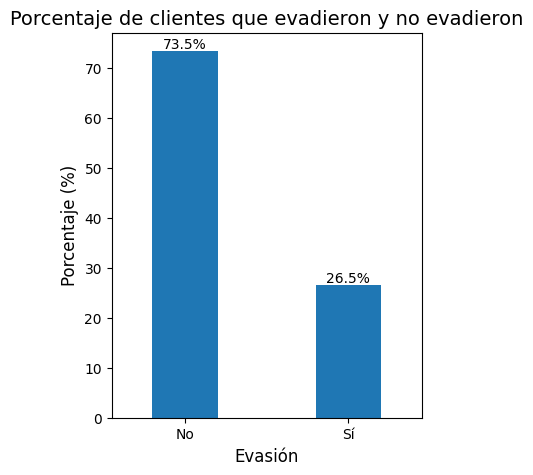

In [31]:
evasion = df_lim['Churn'].value_counts(normalize=True) * 100
evasion = evasion.sort_index()

evasion.index = ['No', 'Sí']
ax = evasion.plot(kind='bar', figsize=(4,5), width=0.4)

plt.title('Porcentaje de clientes que evadieron y no evadieron', fontsize=14)
plt.xlabel('Evasión', fontsize=12)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xticks(rotation=0)

for i, v in enumerate(evasion):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha='center')

plt.show()

###**Evasión por tipo de contrato**

In [46]:

evadidos = df_lim[df_lim['Churn'] == 1]

# contar por tipo de contrato
df_evadidos_contrato = evadidos.groupby('Contract').size().reset_index(name='Total_evadidos')
df_evadidos_contrato['Porcentaje'] = (
    df_evadidos_contrato['Total_evadidos'] /
    df_evadidos_contrato['Total_evadidos'].sum()
) * 100
print(df_evadidos_contrato)

    Contract  Total_evadidos  Porcentaje
0   Dos-años              48    2.568218
1  Mes-a-Mes            1655   88.550027
2     Un-año             166    8.881755


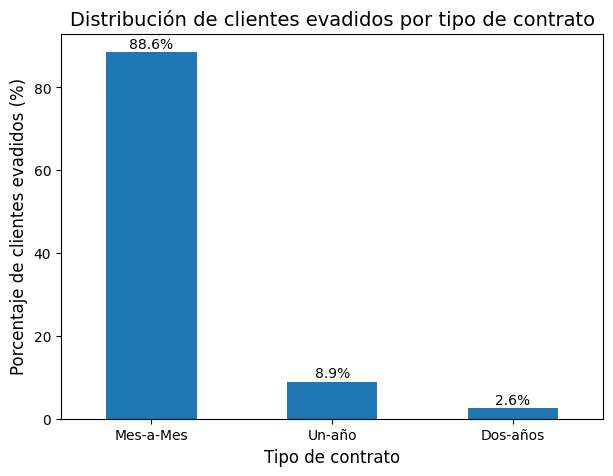

In [40]:
evadidos = df_lim[df_lim['Churn'] == 1]
evasion_porcentaje = evadidos['Contract'].value_counts(normalize=True) * 100
ax = evasion_porcentaje.plot(kind='bar', figsize=(7,5), width=0.5)

for i, v in enumerate(evasion_porcentaje):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title('Distribución de clientes evadidos por tipo de contrato', fontsize=14)
plt.xlabel('Tipo de contrato', fontsize=12)
plt.ylabel('Porcentaje de clientes evadidos (%)', fontsize=12)
plt.xticks(rotation=0)

plt.show()

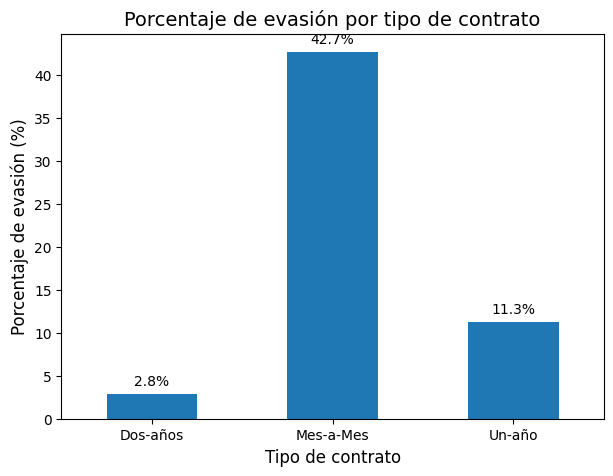

In [25]:
evasion_porcentaje = df_lim.groupby('Contract')['Churn'].mean() * 100
ax = evasion_porcentaje.plot(kind='bar', figsize=(7,5))

for i, v in enumerate(evasion_porcentaje):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.title('Porcentaje de evasión por tipo de contrato',fontsize=14)
plt.xlabel('Tipo de contrato',fontsize=12)
plt.ylabel('Porcentaje de evasión (%)',fontsize=12)
plt.xticks(rotation=0)

plt.show()

### **Evasión por genero**

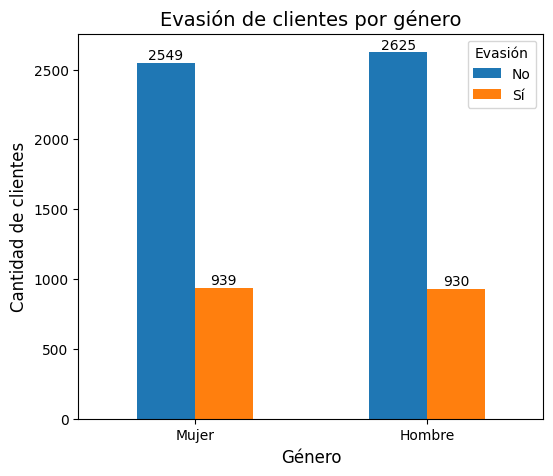

In [27]:
tabla = pd.crosstab(df_lim['gender'], df_lim['Churn'])
tabla.columns = ['No', 'Sí']
tabla.index = ['Mujer', 'Hombre']

ax = tabla.plot(kind='bar', figsize=(6,5), width=0.5)

plt.title('Evasión de clientes por género',fontsize=14)
plt.xlabel('Género',fontsize=12)
plt.ylabel('Cantidad de clientes',fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Evasión')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### **Evasión por metodod de pago**

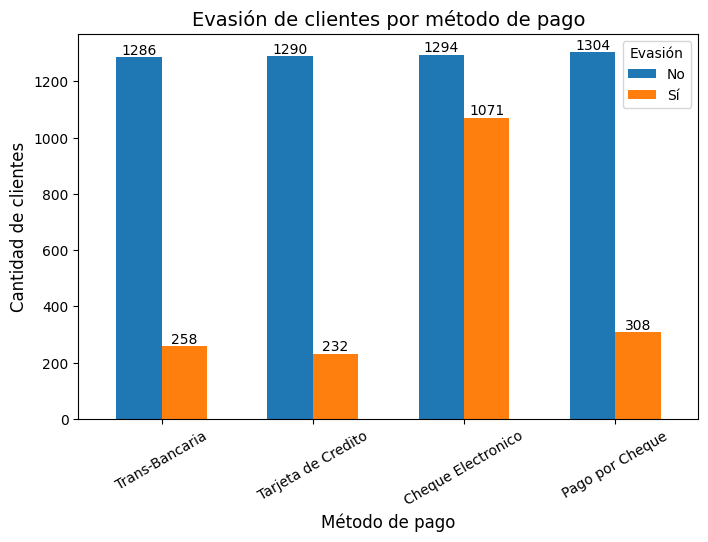

In [28]:
tabla = pd.crosstab(df_lim['PaymentMethod'], df_lim['Churn'])
tabla = tabla.rename(columns={0:'No', 1:'Sí'})
tabla.index = ['Trans-Bancaria', 'Tarjeta de Credito','Cheque Electronico','Pago por Cheque']

ax = tabla.plot(kind='bar', figsize=(8,5), width=0.6)

plt.title('Evasión de clientes por método de pago',fontsize=14)
plt.xlabel('Método de pago',fontsize=12)
plt.ylabel('Cantidad de clientes',fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Evasión')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### **Evasión por costos totales**

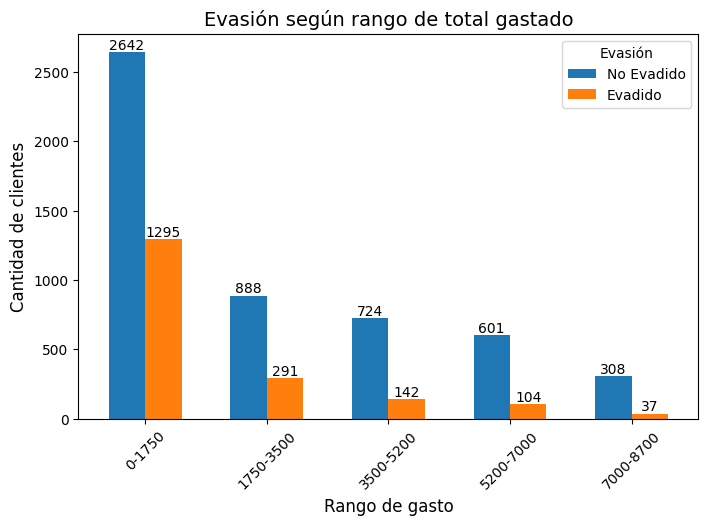

In [29]:
tabla = pd.crosstab(pd.cut(df_lim['Charges.Total'], bins=5), df_lim['Churn'])
tabla = tabla.rename(columns={0:'No Evadido', 1:'Evadido'})
tabla.index = ['0-1750','1750-3500','3500-5200','5200-7000','7000-8700']
ax = tabla.plot(kind='bar', figsize=(8,5), width=0.6)

plt.title('Evasión según rango de total gastado',fontsize=14)
plt.xlabel('Rango de gasto',fontsize=12)
plt.ylabel('Cantidad de clientes',fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Evasión')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [30]:
df_lim.head(2)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Charges.daily
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,Un-año,1,Mailed check,65.6,593.3,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Mes-a-Mes,0,Mailed check,59.9,542.4,2.00


## **📋  ​Informe Final**

### **1. Introducción**

El objetivo de este proyecto es analizar e identificar las razones o patrones que llevan a los clientes a cancelar sus servicios. Se detectaran los motivos de evasión para asi la empresa pueda tomar medidas ante esta situación.

### **2. Limpieza y Tratamiento de Datos**

Se obtuviron los datos de los clientes de la empresa para realizar el analisis de evasión de clientes. Se extrajeron con la biblioteca pandas, se inicion la limpieza de los datos, eliminando caracteres inecesarios y tartando datos nulos o vacios. Se procedio a transformar los datos para un analisis más preciso y claro.

### **3. Analisis exploratorio de lo datos (EDA)**

El analisis de los datos dio varios insights valiosos.

* El listado tiene 7.267 clientes de los cuales cuales 1.869 se han retirado, esos 1.869 clinetes equivalen al 26.5% de los clientes.
* Por tipo de  contrato, el contrato que genera mas retiros de clientes es de Mes a Mes, con un total de 1.655 clientes que equivalen al 88.5 de los clinetes evadidos.
* Con respecto al metodo de pago los clientes que pagan de forma electronica tienen la mayor evasión de cientes.
* Los clietes con un menor gasto total son los que mas evaden.

###**4.  Conclusiones e Insights**

Las caracteristicas de los clientes que se retiran son: contratos a corto plazo, pagos electronicos, planes de bajo costo. Estas caracteristicas son los mayores predictores de fuga de clientes.

### ***5. Recomendaciones**

* Generar fidelidad con planes, descuentos y bonos a los clinetes.
* Ofrecer descuentos en el pago mensual por pasar al plan anual.
* incentivar el pago con tajeta de credito para mitigar el pago electronico.